In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [149]:
df = pd.read_csv("thyroid_dataset.csv")

In [150]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [151]:
X = df.drop("Outlier_label",axis = 1)
y = df["Outlier_label"]

In [152]:
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [153]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest

In [154]:
from sklearn.ensemble import IsolationForest

In [155]:
clf = IsolationForest(
    n_estimators = 200,
    contamination = 0.036,
    random_state=42
)

iso_labels = clf.fit_predict(X_scaled)

In [156]:
iso_labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [157]:
# Visualize
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

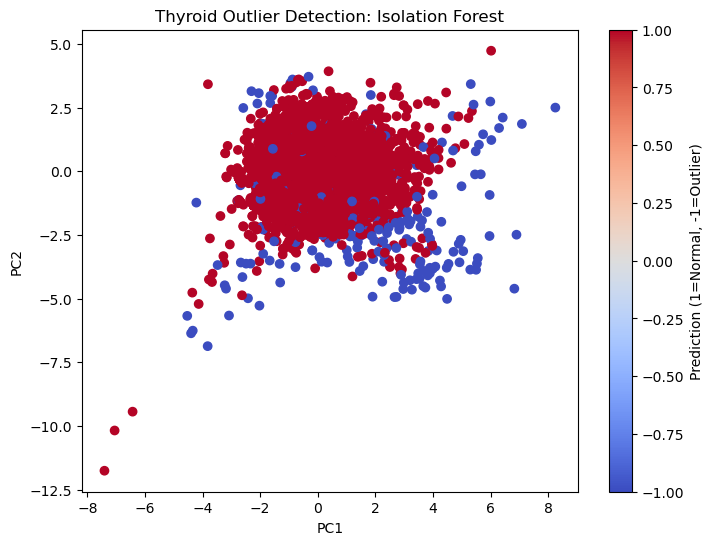

In [158]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=iso_labels,cmap="coolwarm")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Thyroid Outlier Detection: Isolation Forest")
plt.colorbar(label='Prediction (1=Normal, -1=Outlier)')
plt.show()

In [159]:
n_outliers = np.sum(iso_labels == -1)
n_normal = np.sum(iso_labels == 1)

print("Outliers:",n_outliers)
print("Normal:",n_normal)

Outliers: 249
Normal: 6667


# LOF

In [160]:
from sklearn.neighbors import LocalOutlierFactor

In [161]:
neighbs = LocalOutlierFactor(contamination = 0.036)
loc_labels = neighbs.fit_predict(X_scaled)                            

In [162]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

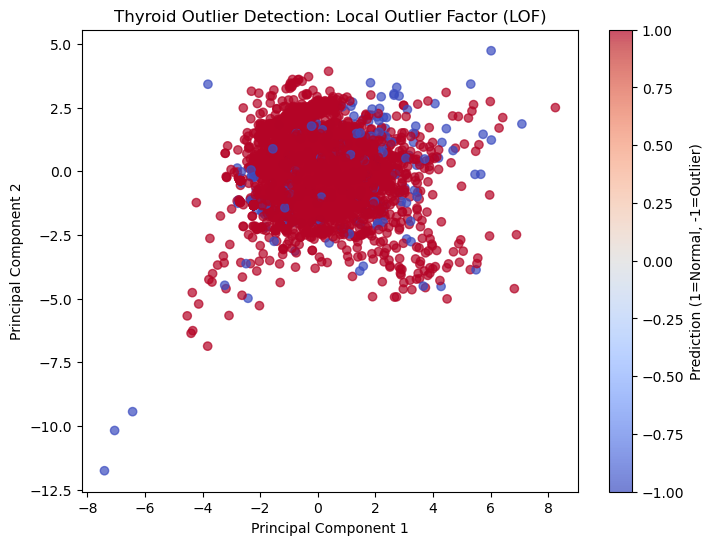

In [163]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=loc_labels, cmap='coolwarm', alpha=0.7)
plt.title("Thyroid Outlier Detection: Local Outlier Factor (LOF)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Prediction (1=Normal, -1=Outlier)')
plt.show()

In [164]:
n_outliers = np.sum(loc_labels == -1)
n_normal = np.sum(loc_labels == 1)

print("Outliers:",n_outliers)
print("Normal:",n_normal)

Outliers: 249
Normal: 6667


# DBSCAN

In [169]:
from sklearn.cluster import DBSCAN

In [170]:
dbscan = DBSCAN(eps=2.4, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

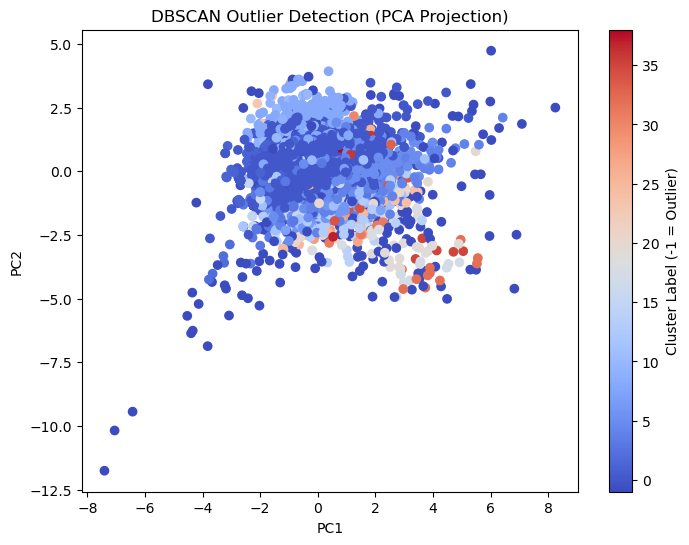

In [171]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='coolwarm')
plt.title("DBSCAN Outlier Detection (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster Label (-1 = Outlier)')
plt.show()

In [167]:
n_outliers = np.sum(db_labels == -1)
n_normal = np.sum(db_labels != -1) 

print("Outliers:", n_outliers)
print("Normal:", n_normal)

Outliers: 257
Normal: 6659


In [172]:
results = pd.DataFrame({
    "Method": ["Isolation Forest", "LOF", "DBSCAN"],
    "Outliers Detected": [
        np.sum(iso_labels == -1),
        np.sum(loc_labels == -1),
        np.sum(db_labels == -1)
    ]
})
print(results)

             Method  Outliers Detected
0  Isolation Forest                249
1               LOF                249
2            DBSCAN                257
